<a href="https://colab.research.google.com/github/dashsumit/Projects/blob/main/Email_SMS_SPAM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
from collections import Counter as cn
from string import punctuation

import matplotlib.pyplot as plt  # correct way
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from nltk import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.ensemble import AdaBoostClassifier  # AdaBoost
from sklearn.ensemble import BaggingClassifier  # Bagging
from sklearn.ensemble import ExtraTreesClassifier  # Extra Trees
from sklearn.ensemble import GradientBoostingClassifier  # Gradient Boosting
from sklearn.ensemble import RandomForestClassifier  # Random Forest
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression  # Logistic Regression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier  # K-Nearest Neighbors
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC  # Support Vector Machine
from sklearn.tree import DecisionTreeClassifier  # Decision Tree
from spacy.lang.en.stop_words import STOP_WORDS
from wordcloud import WordCloud
from xgboost import XGBClassifier  # XGBoost
from sklearn.ensemble import VotingClassifier

# ----------------------------
# Classic classifiers
# ----------------------------


# ----------------------------
# Ensemble methods (bagging & boosting)
# ----------------------------


# ----------------------------
# XGBoost (needs separate library)
# ----------------------------


warnings.filterwarnings("ignore")

In [ ]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv("spam.csv", encoding="latin1")
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)

In [ ]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


# 1/  Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## Renaming The Columns Name

In [ ]:
df.rename(columns={"v1": "target", "v2": "text"}, inplace=True)
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
encoder = LabelEncoder()
df["target"] = encoder.fit_transform(df["target"])

In [ ]:
df  # 0=ham . 1= spam

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [ ]:
df.isnull().sum()

,0
target,0
text,0


In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
# removing the duplicates
df.drop_duplicates(keep="first", inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(5169, 2)

# EDA

In [ ]:
df["target"].value_counts()

,count
target,
0,4516
1,653


## Pie Chart

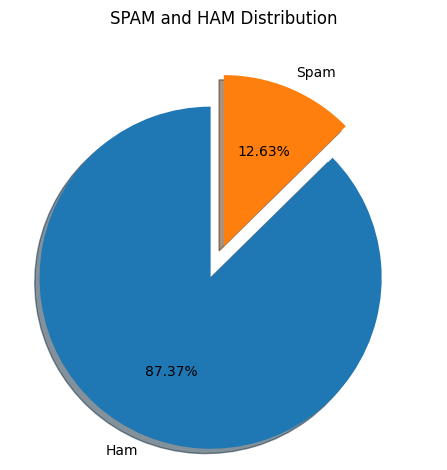

In [ ]:
# Too many categories

# languages = ['Python', 'Java', 'C++', 'JavaScript', 'C#', 'Ruby', 'Others']
# usage = [30, 20, 10, 10, 7, 5, 10]
explode = [0.2, 0]

plt.pie(
    df["target"].value_counts(),
    labels=["Ham", "Spam"],
    autopct="%1.2f%%",
    startangle=90,
    shadow=True,
    explode=explode,
)
plt.title("SPAM and HAM Distribution")
plt.tight_layout()
plt.show()

## Here Data is Imbalanced

### We have a another concern that in our sms how many alphabets and char and sentences are using . so for that we will use nltk

In [ ]:
# NUm of char
df["num_char"] = df["text"].apply(len)

In [ ]:
# Num of words
df["num_words"] = df["text"].apply(lambda x: len(nltk.word_tokenize(x)))

In [ ]:
# num of sentence

df["num_sent"] = df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))

In [ ]:
df[["num_char", "num_words", "num_sent"]].describe()

,num_char,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
# Describe for ham

df[df["target"] == 0][["num_char", "num_words", "num_sent"]].describe()

,num_char,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
# describe for SPAM
df[df["target"] == 1][["num_char", "num_words", "num_sent"]].describe()

,num_char,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


## Hist by Seaborn

### Number of Characters(SPAM/HAM)

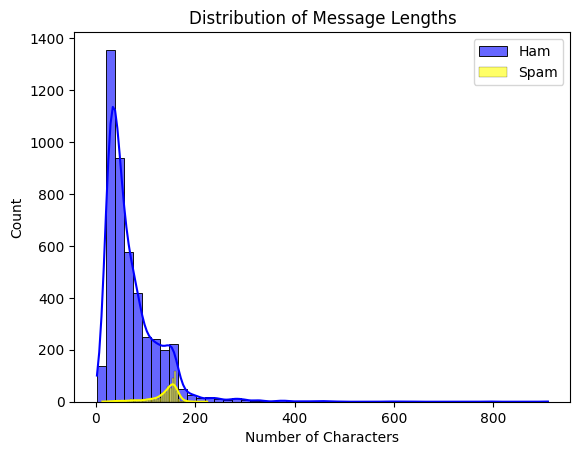

In [ ]:
# Plot histogram of number of characters
# plt.figure(figsize=(10,6))
sns.histplot(
    df[df["target"] == 0]["num_char"],
    color="blue",
    label="Ham",
    kde=True,
    bins=50,
    alpha=0.6,
)
sns.histplot(
    df[df["target"] == 1]["num_char"],
    color="yellow",
    label="Spam",
    kde=True,
    bins=50,
    alpha=0.6,
)

plt.xlabel("Number of Characters")
plt.ylabel("Count")
plt.title("Distribution of Message Lengths")
plt.legend()
plt.show()

### Number of Words(SPAM/HAM)

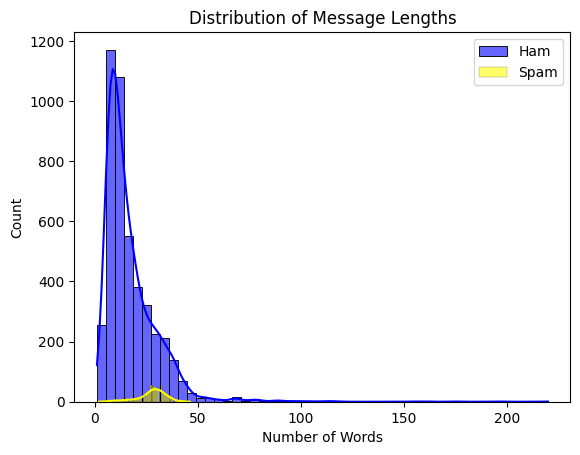

In [ ]:
# Plot histogram of number of characters
# plt.figure(figsize=(10,6))
sns.histplot(
    df[df["target"] == 0]["num_words"],
    color="blue",
    label="Ham",
    kde=True,
    bins=50,
    alpha=0.6,
)
sns.histplot(
    df[df["target"] == 1]["num_words"],
    color="yellow",
    label="Spam",
    kde=True,
    bins=50,
    alpha=0.6,
)

plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.title("Distribution of Message Lengths")
plt.legend()
# plt.tight_layout()
plt.show()

### Number of Sentences(SPAM/HAM)

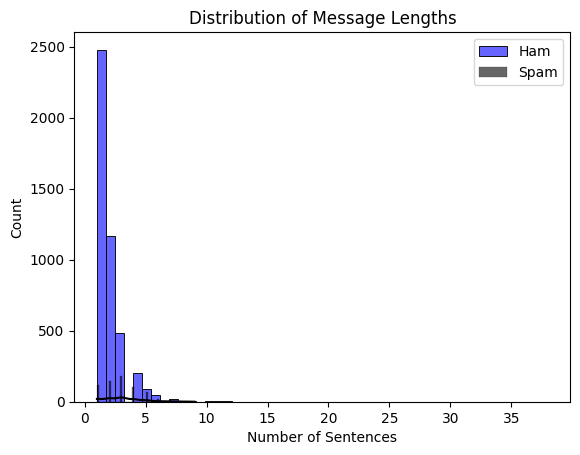

In [ ]:
# Plot histogram of number of SEntences
# plt.figure(figsize=(12,8))
sns.histplot(
    df[df["target"] == 0]["num_sent"],
    color="blue",
    label="Ham",
    kde=False,
    bins=50,
    alpha=0.6,
)
sns.histplot(
    df[df["target"] == 1]["num_sent"],
    color="black",
    label="Spam",
    kde=True,
    bins=50,
    alpha=0.6,
)

plt.xlabel("Number of Sentences")
plt.ylabel("Count")
plt.title("Distribution of Message Lengths")
plt.legend()
plt.show()

## Pairplot

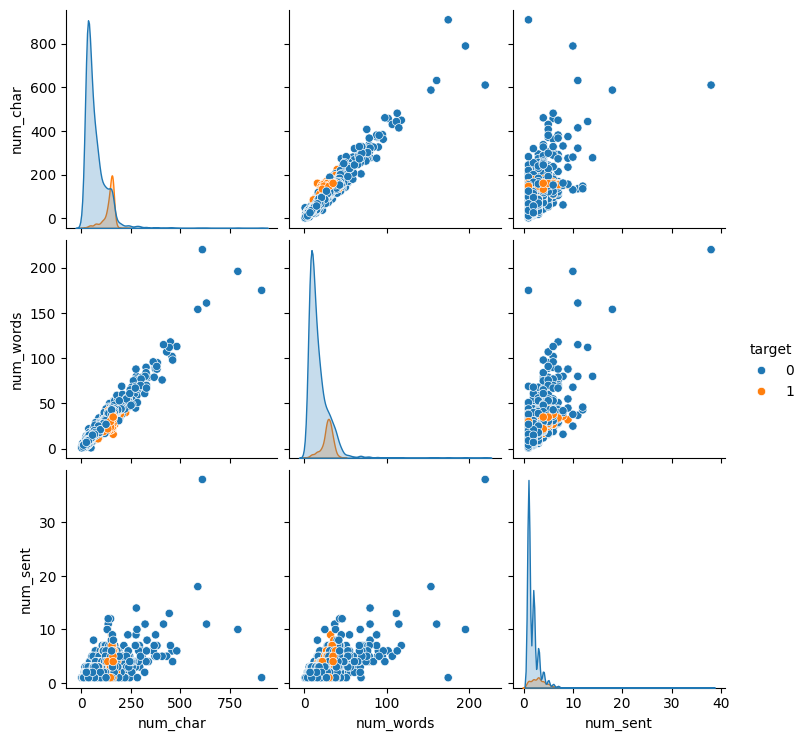

In [ ]:
sns.pairplot(df, hue="target")

In [ ]:
corr = df.corr(numeric_only=True)
corr

,target,num_char,num_words,num_sent
target,1.000000,0.384717,0.262912,0.263939
num_char,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sent,0.263939,0.624139,0.679971,1.000000


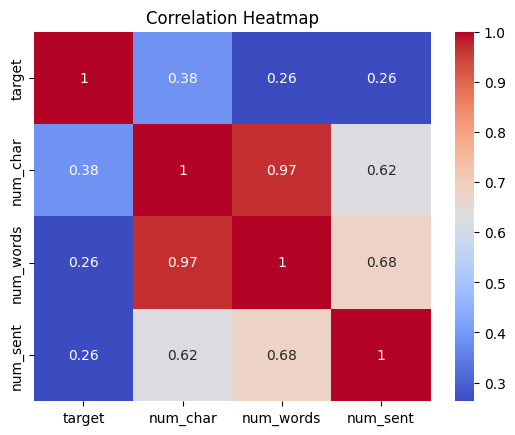

In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
# plt.tight_layout()
plt.show()

## Data Preprocessing

#### stopwords
#### steming
#### vectorizing
#### lower_case
#### tokenization
#### remove_special_char

In [ ]:
ps = PorterStemmer()
ps.stem("dancing")

'danc'

In [ ]:
def transform_text(text):
    text = text.lower()  # lowercase
    tokens = word_tokenize(text)  # tokenize

    stop_words = set(stopwords.words("english"))  # load once

    # Keep only alphanumeric words and remove stopwords
    words = [word for word in tokens if word.isalnum() and word not in stop_words]

    # text= y[:] # creating copy of text
    # y.clear()

    # for i in text.split():
    #    y.append(ps.stem(i))

    # return " ".join(y)

    # Apply stemming
    stemmed = [ps.stem(word) for word in words]

    return " ".join(stemmed)

In [ ]:
transform_text(" i loved the YT lectures on Machine Learning Videos. How About you ? ")

'love yt lectur machin learn video'

### STemming Function

In [ ]:
# def stem(text):
#   y = []
#   for i in text.split():
#     y.append(ps.stem(i))
#   return " ".join(y)

In [ ]:
df["transform"] = df["text"].apply(transform_text)
df

,target,text,num_char,num_words,num_sent,transform
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


# Word Cloud

## Using word cloud to see specifiq Spam/Ham Msgs

In [ ]:
wc = WordCloud(width=1000, height=1000, min_font_size=10, background_color="white")

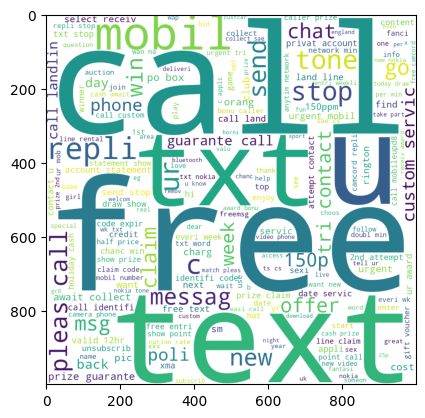

In [ ]:
spam_wc = wc.generate(df[df["target"] == 1]["transform"].str.cat(sep=" "))
plt.imshow(spam_wc)

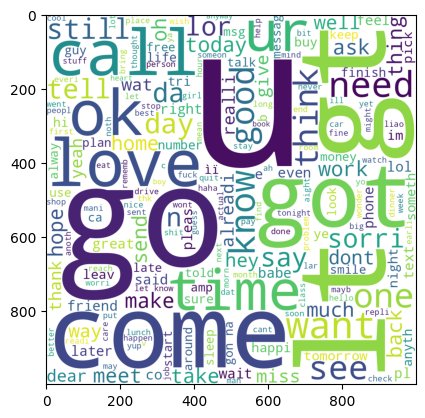

In [ ]:
ham_wc = wc.generate(df[df["target"] == 0]["transform"].str.cat(sep=" "))
plt.imshow(ham_wc)

# Findinf Top 30 Spam Words

In [ ]:
spam_corpus = []
for msg in df[df["target"] == 1]["transform"].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [ ]:
len(spam_corpus)

9939

## Counter to count the spam Msgs

In [ ]:
cn(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [ ]:
df1 = pd.DataFrame(cn(spam_corpus).most_common(30))[0]  # 0 means 1st columns
df2 = pd.DataFrame(cn(spam_corpus).most_common(30))[1]  # 1 means 2nd columns

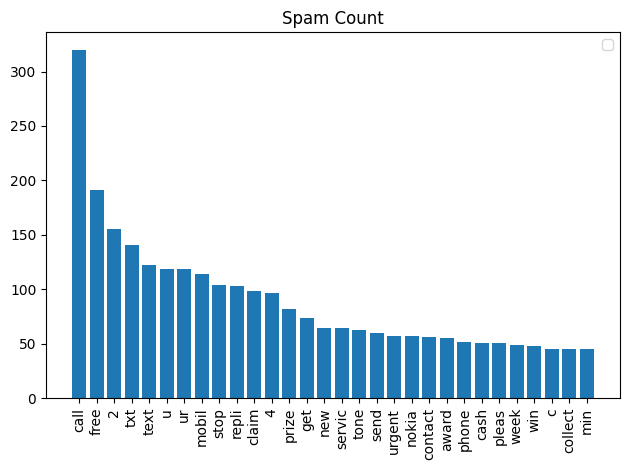

In [ ]:
plt.bar(df1, df2)

plt.title("Spam Count")
plt.xticks(rotation="vertical")  # Show actual year instead of 0,1,2,...
plt.legend()
plt.tight_layout()

plt.style.use("ggplot")
plt.show()

# Finding Top 30 Ham words

In [ ]:
ham_corpus = []
for msg in df[df["target"] == 0]["transform"].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [ ]:
len(ham_corpus)

35404

## Counter to count the Ham msgs

In [ ]:
cn(ham_corpus).most_common(30)

[('u', 883),
 ('go', 404),
 ('get', 349),
 ('gt', 288),
 ('lt', 287),
 ('2', 284),
 ('come', 275),
 ('got', 236),
 ('know', 236),
 ('like', 234),
 ('call', 233),
 ('time', 219),
 ('ok', 217),
 ('love', 216),
 ('good', 213),
 ('want', 208),
 ('ur', 197),
 ('day', 190),
 ('need', 170),
 ('one', 165),
 ('lor', 159),
 ('4', 156),
 ('home', 152),
 ('think', 149),
 ('see', 147),
 ('take', 143),
 ('still', 143),
 ('da', 142),
 ('tell', 133),
 ('make', 129)]

In [ ]:
df3 = pd.DataFrame(cn(ham_corpus).most_common(30))[0]  # 0 means 1st columns
df4 = pd.DataFrame(cn(ham_corpus).most_common(30))[1]  # 1 means 2nd columns

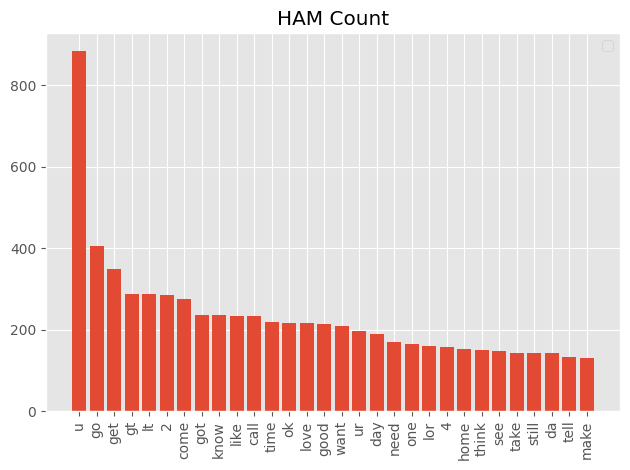

In [ ]:
plt.bar(df3, df4)

plt.title("HAM Count")
plt.xticks(rotation="vertical")  # Show actual year instead of 0,1,2,...
plt.legend()
plt.tight_layout()

plt.style.use("ggplot")
plt.show()

# Model_Building

In [ ]:
cv = CountVectorizer()

In [ ]:
x = cv.fit_transform(df["transform"]).toarray()

In [ ]:
x.shape

(5169, 6708)

In [ ]:
y = df["target"].values

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=42)

# Obj of Naiva_bayes

In [ ]:
gnb = GaussianNB()
mulnb = MultinomialNB()
bnb = BernoulliNB()

## GaussianNB

In [ ]:
gnb.fit(x_train, y_train)
y_pred1 = gnb.predict(x_test)
print(f"Accuracy Score of GaussianNB is {accuracy_score(y_test,y_pred1)}")
print(f"Precision Score of GaussianNB is {precision_score(y_test,y_pred1)}")

Accuracy Score of GaussianNB is 0.8333333333333334
Precision Score of GaussianNB is 0.5384615384615384


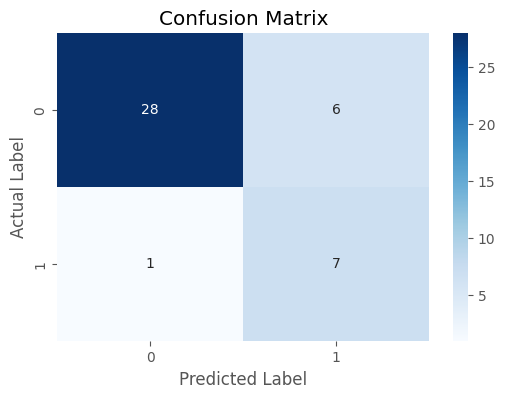

In [ ]:
cm = confusion_matrix(y_test, y_pred1)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Blues", cbar=True)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## MultinomialNB

In [ ]:
mulnb.fit(x_train, y_train)
y_pred2 = mulnb.predict(x_test)
print(f"Accuracy Score of MultiNB is {accuracy_score(y_test,y_pred2)}")
print(f"Precision Score of MultiNB is {precision_score(y_test,y_pred2)}")

Accuracy Score of MultiNB is 0.9761904761904762
Precision Score of MultiNB is 0.8888888888888888


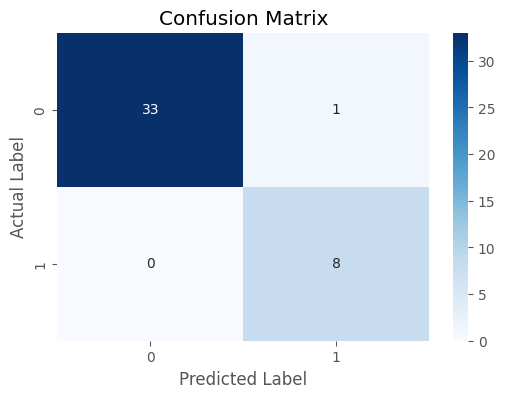

In [ ]:
cm = confusion_matrix(y_test, y_pred2)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Blues", cbar=True)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## BernoulliNB

In [ ]:
bnb.fit(x_train, y_train)
y_pred3 = bnb.predict(x_test)
print(f"Accuracy Score of BernoulliNB is {accuracy_score(y_test,y_pred3)}")
print(f"Precision Score of BernoulliNB is {precision_score(y_test,y_pred3)}")

Accuracy Score of BernoulliNB is 1.0
Precision Score of BernoulliNB is 1.0


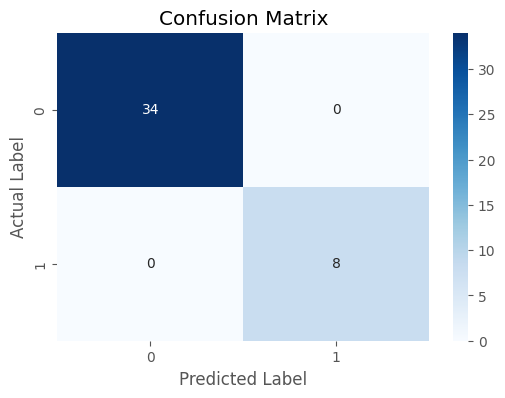

In [ ]:
cm = confusion_matrix(y_test, y_pred3)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Blues", cbar=True)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# Comparing All Models

## Objects of All Models

In [ ]:
# Initialize all classifiers
svc = SVC(kernel="sigmoid", gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver="liblinear", penalty="l1")
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [ ]:
models = {
    "SVC": svc,
    "KNN": knc,
    "MultinomialNB": mnb,
    "DecisionTreeClassifier": dtc,
    "LogisticRegression": lrc,
    "RandomForestClassifier": rfc,
    "AdaBoostClassifier": abc,
    "BaggingClassifier": bc,
    "ExtraTreesClassifier": etc,
    "GradientBoostingClassifier": gbdt,
    "XGBClassifier": xgb,
}

In [ ]:
def train_classifier(models, x_train, x_test, y_train, y_test):
    models.fit(x_train, y_train)
    y_pred = models.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [ ]:
accuracies = []
precisions = []

for name, model in models.items():
    current_accuracy, current_precision = train_classifier(
        model, x_train, x_test, y_train, y_test
    )
    print(f" For {name}")
    print(f"Accuracy_Score {current_accuracy} ")
    print(f"precision_score {current_precision} ")

    accuracies.append(current_accuracy)
    precisions.append(current_precision)

 For SVC
Accuracy_Score 0.9047619047619048 
precision_score 0.7 
 For KNN
Accuracy_Score 0.9047619047619048 
precision_score 1.0 
 For MultinomialNB
Accuracy_Score 0.9761904761904762 
precision_score 0.8888888888888888 
 For DecisionTreeClassifier
Accuracy_Score 0.8809523809523809 
precision_score 1.0 
 For LogisticRegression
Accuracy_Score 1.0 
precision_score 1.0 
 For RandomForestClassifier
Accuracy_Score 0.9761904761904762 
precision_score 1.0 
 For AdaBoostClassifier
Accuracy_Score 0.9047619047619048 
precision_score 1.0 
 For BaggingClassifier
Accuracy_Score 1.0 
precision_score 1.0 
 For ExtraTreesClassifier
Accuracy_Score 0.9761904761904762 
precision_score 1.0 
 For GradientBoostingClassifier
Accuracy_Score 0.9761904761904762 
precision_score 1.0 
 For XGBClassifier
Accuracy_Score 1.0 
precision_score 1.0 


In [ ]:
df_score=pd.DataFrame({'Model':models.keys(),'Accuracy':accuracies,'Precision':precisions}).sort_values(by=['Accuracy','Precision'],ascending=False)
df_score

,Model,Accuracy,Precision
4,LogisticRegression,1.000000,1.000000
7,BaggingClassifier,1.000000,1.000000
10,XGBClassifier,1.000000,1.000000
5,RandomForestClassifier,0.976190,1.000000
8,ExtraTreesClassifier,0.976190,1.000000
9,GradientBoostingClassifier,0.976190,1.000000
2,MultinomialNB,0.976190,0.888889
1,KNN,0.904762,1.000000
6,AdaBoostClassifier,0.904762,1.000000
0,SVC,0.904762,0.700000


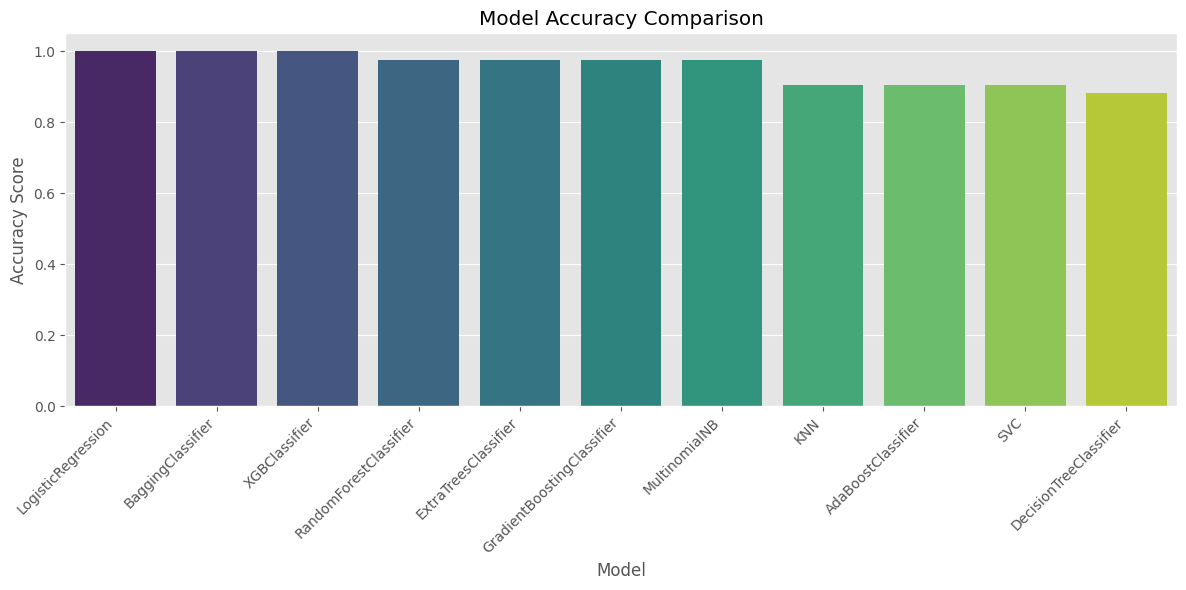

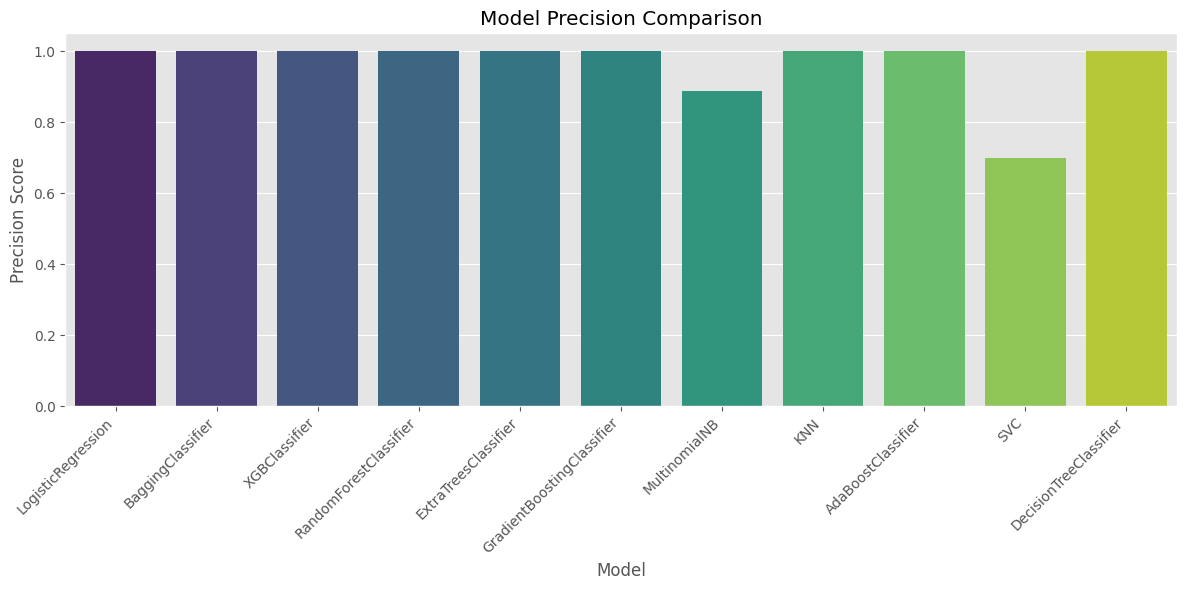

In [ ]:
# Plotting Accuracy
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=df_score, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting Precision
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Precision', data=df_score, palette='viridis')
plt.title('Model Precision Comparison')
plt.ylabel('Precision Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Voting Classifier

In [ ]:
# Create a list of estimators for the Voting Classifier based on the specified indices
selected_models = [list(models.items())[i] for i in [4, 7, 10, 5, 8, 9, 2]]

vote = VotingClassifier(estimators=selected_models, voting="soft")

In [ ]:
vote.fit(x_train,y_train)

VotingClassifier(estimators=[('LogisticRegression',
                              LogisticRegression(penalty='l1',
                                                 solver='liblinear')),
                             ('BaggingClassifier',
                              BaggingClassifier(n_estimators=50,
                                                random_state=2)),
                             ('XGBClassifier',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_round...
                                            n_estimators=50, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('RandomForestClassifier',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=2)),
                             ('ExtraTreesClassifier',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2)),
                             ('GradientBoostingClassifier',
                              GradientBoostingClassifier(n_estimators=50,
                                                         random_state=2)),
                             ('MultinomialNB', MultinomialNB())],
                 voting='soft')